In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

plt.style.use(["science", "no-latex", "notebook"])

In [8]:
# Locate all npz sweep files in the current folder
npz_files = sorted(Path(".").glob("*_s_sweep.npz"))
if not npz_files:
    npz_files = sorted(Path(".").glob("*.npz"))

positions = []
s21_data = []
freqs_ghz = None

# Extract data from each file
for fpath in npz_files:
    with np.load(fpath) as data:
        # Extract ground position scalar
        pos = float(data["ground_pos_mm"])

        # Extract frequencies once
        if freqs_ghz is None:
            freqs_ghz = data["freq_hz"] / 1e9

        # Calculate |S21| in dB
        s21 = data["S21"]
        # s21_db = 20 * np.log10(np.abs(s21))
        s21_db = np.angle(s21)

        positions.append(pos)
        s21_data.append(s21_db)

In [9]:
# Convert to arrays and sort by position to handle out-of-order completion
positions = np.array(positions)
s21_matrix = np.array(s21_data)  # Shape: (n_positions, n_freqs)

sort_idx = np.argsort(positions)
positions = positions[sort_idx]
s21_matrix = s21_matrix[sort_idx, :]

# Create 2D meshgrid for plotting (X: position, Y: frequency)
X, Y = np.meshgrid(positions, freqs_ghz)
Z = s21_matrix.T  # Transpose to shape: (n_freqs, n_positions)

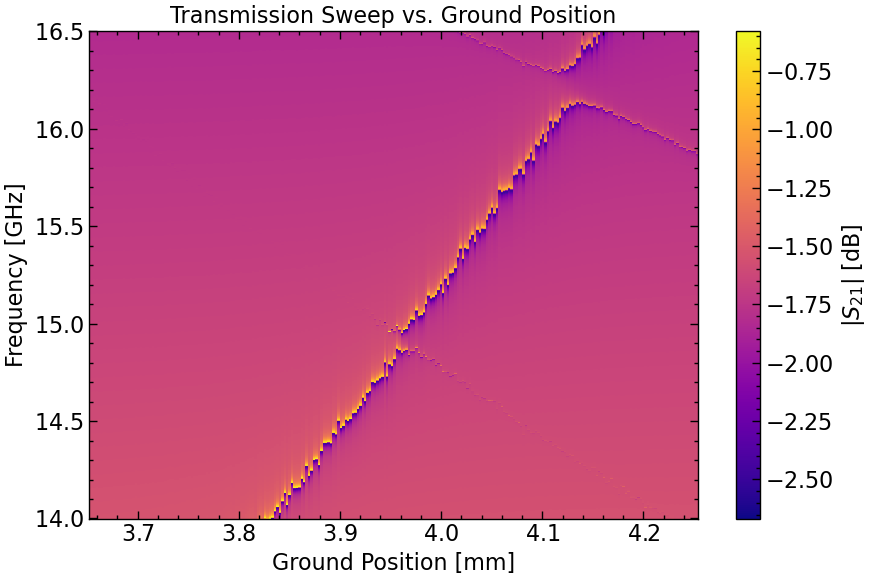

In [10]:
# Plot colormap
fig, ax = plt.subplots(figsize=(9, 6))

mesh = ax.pcolormesh(X, Y, Z, shading="auto", cmap="plasma")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"$\vert S_{21} \vert$ [dB]")

ax.set_xlabel("Ground Position [mm]")
ax.set_ylabel("Frequency [GHz]")
ax.set_title("Transmission Sweep vs. Ground Position")

plt.tight_layout()
plt.show()

In [11]:
import pint

ureg = pint.UnitRegistry()

bare_frequency = ureg.Quantity(15.0324, 'GHz')
resonator_full_length = ureg.Quantity(5.92905, 'mm')

velocity = 4.0 * resonator_full_length * bare_frequency / 3.0
velocity = velocity.to_base_units()

In [12]:
resonator_length = 5.92905
segment_a = positions
segment_b = resonator_length - positions

freq_a = velocity / ureg.Quantity(segment_a, 'mm')
freq_a = freq_a.to_base_units().to('GHz')
freq_b = velocity / ureg.Quantity(segment_b, 'mm')
freq_b = freq_b.to_base_units().to('GHz')


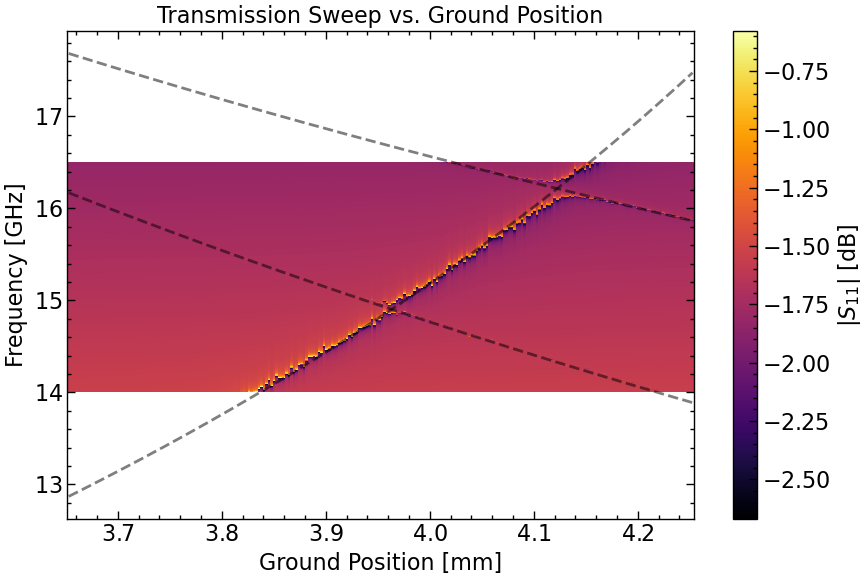

In [16]:
# Plot colormap
fig, ax = plt.subplots(figsize=(9, 6))

mesh = ax.pcolormesh(X, Y, Z, shading="auto", cmap="inferno")

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"$\vert S_{11} \vert$ [dB]")

ax.set_xlabel("Ground Position [mm]")
ax.set_ylabel("Frequency [GHz]")
ax.set_title("Transmission Sweep vs. Ground Position")
ax.plot(positions, 0.994 * 0.5 *freq_a.magnitude, color = 'black', linestyle = 'dashed', alpha = 0.5)
ax.plot(positions, 0.99*0.4*freq_a.magnitude+4.8, color = 'black', linestyle = 'dashed', alpha = 0.5)
ax.plot(positions, 0.986 * 0.25 * freq_b.magnitude, color = 'black', linestyle = 'dashed', alpha = 0.5)
# ax.set_ylim(14.0, 16.5)
plt.tight_layout()
plt.show()

In [8]:
1.14 * 0.985 * 0.5

0.5614499999999999